# Marketing Mix ROI Model

Business question: which paid media channels explain sales, and does cross-channel interaction matter?
Public advertising dataset with TV, radio, newspaper spend, and sales.
Dataset: [Advertising](https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot') # use ggplot style here for variety


In [ ]:
df_adv = pd.read_csv('../data/advertising.csv')
if 'Unnamed: 0' in df_adv.columns:
    df_adv = df_adv.drop(columns=['Unnamed: 0'])
df_adv.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df_adv.describe().T # transposing describe for variety


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [ ]:
df_adv.isnull().sum()


TV           0
radio        0
newspaper    0
sales        0
dtype: int64

A quick channel-vs-sales view helps decide whether a linear baseline is reasonable.

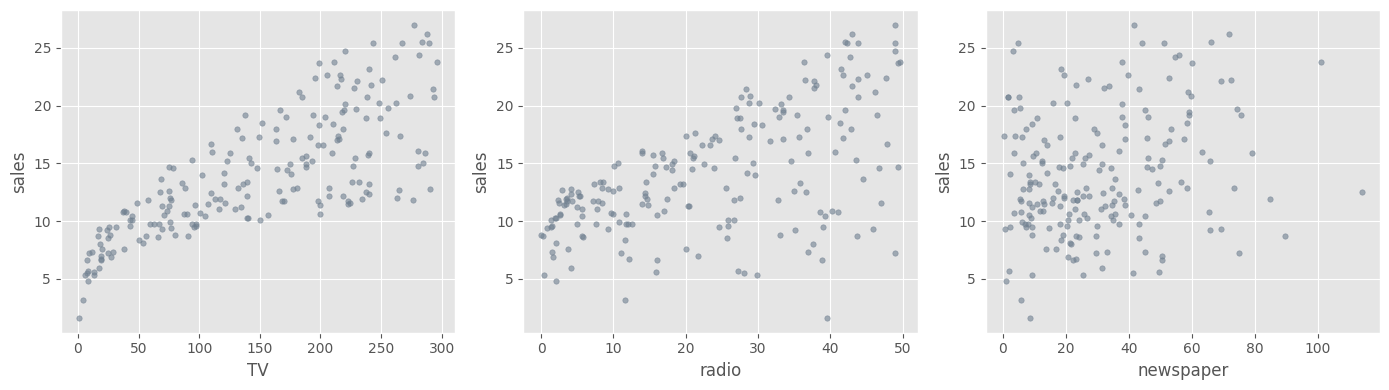

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
channels = ['TV', 'radio', 'newspaper']
for i, ch in enumerate(channels):
    axes[i].scatter(df_adv[ch], df_adv['sales'], alpha=0.6, color='#708090', s=15)
    axes[i].set_xlabel(ch)
    axes[i].set_ylabel('sales')
plt.tight_layout()
plt.show()


TV has the clearest relationship with sales; radio is weaker, and newspaper spend looks noisy.
Correlations confirm the same picture.

In [ ]:
df_adv.corr(method='pearson').round(3)


,TV,radio,newspaper,sales
TV,1.000,0.055,0.057,0.782
radio,0.055,1.000,0.354,0.576
newspaper,0.057,0.354,1.000,0.228
sales,0.782,0.576,0.228,1.000


In [ ]:
df_adv.corr(method='spearman').round(3)


,TV,radio,newspaper,sales
TV,1.000,0.056,0.051,0.801
radio,0.056,1.000,0.317,0.554
newspaper,0.051,0.317,1.000,0.195
sales,0.801,0.554,0.195,1.000


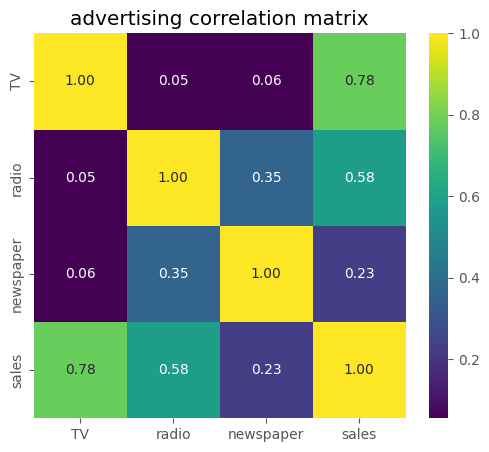

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_adv.corr(), annot=True, fmt='.2f', cmap='viridis')
plt.title('advertising correlation matrix')
plt.show()


### fitting OLS regression

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

X_matrix = df_adv[['TV', 'radio', 'newspaper']]
X_matrix_const = sm.add_constant(X_matrix)
y_vector = df_adv['sales']

ols_model = sm.OLS(y_vector, X_matrix_const).fit()
ols_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        01:43:18   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### baseline model readout
The full model is kept as a benchmark. Channel p-values, residual checks, and AIC/BIC decide whether the simpler or interaction model is more useful.

### residual assumption checks

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

resids_ols = ols_model.resid
predicted_sales = ols_model.fittedvalues


In [ ]:
print("Durbin-Watson:", round(durbin_watson(resids_ols), 4))


Durbin-Watson: 2.0836


In [ ]:
import scipy.stats as stats
print("Shapiro-Wilk:", stats.shapiro(resids_ols))


Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9176652036187535), pvalue=np.float64(3.938571556266366e-09))


In [ ]:
jb_stat, jb_p = stats.jarque_bera(resids_ols)
skew_val = stats.skew(resids_ols)
kurt_val = stats.kurtosis(resids_ols)
print(f"JB stat: {jb_stat:.4f}  p-val: {jb_p:.4f}")
print(f"skewness: {skew_val:.4f}  kurtosis: {kurt_val:.4f}")


JB stat: 151.2414  p-val: 0.0000
skewness: -1.3274  kurtosis: 3.3319


In [ ]:
bp_stat, bp_p, f_stat, f_p = het_breuschpagan(resids_ols, X_matrix_const)
print(f"Breusch-Pagan p-val: {bp_p:.4f}")


Breusch-Pagan p-val: 0.1623


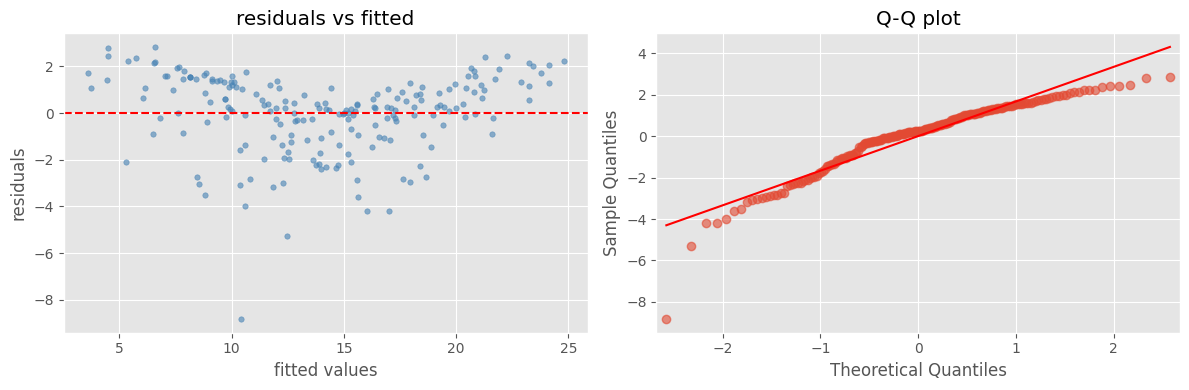

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(predicted_sales, resids_ols, alpha=0.6, color='#4682b4', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('residuals vs fitted')
axes[0].set_xlabel('fitted values')
axes[0].set_ylabel('residuals')

sm.qqplot(resids_ols, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title('Q-Q plot')
plt.tight_layout()
plt.show()


In [ ]:
vif_df = pd.DataFrame()
vif_df['feature'] = X_matrix_const.columns
vif_df['VIF'] = [variance_inflation_factor(X_matrix_const.values, i) for i in range(X_matrix_const.shape[1])]
print(vif_df[vif_df['feature'] != 'const'])


     feature       VIF
1         TV  1.004611
2      radio  1.144952
3  newspaper  1.145187


VIF is well below 5 for all channels.
Newspaper spend adds little signal, while TV and radio can reinforce each other. Compare a reduced model with an interaction model.

In [ ]:
X_reduced = df_adv[['TV', 'radio']]
X_reduced_const = sm.add_constant(X_reduced)
reduced_model = sm.OLS(y_vector, X_reduced_const).fit()

df_adv['TV_Radio_interaction'] = df_adv['TV'] * df_adv['radio']
X_interaction = df_adv[['TV', 'radio', 'TV_Radio_interaction']]
X_interaction_const = sm.add_constant(X_interaction)
interaction_model = sm.OLS(y_vector, X_interaction_const).fit()

print(f"full model:        AIC={ols_model.aic:.2f}  BIC={ols_model.bic:.2f}  R2={ols_model.rsquared:.4f}")
print(f"reduced model:     AIC={reduced_model.aic:.2f}  BIC={reduced_model.bic:.2f}  R2={reduced_model.rsquared:.4f}")
print(f"interaction model: AIC={interaction_model.aic:.2f}  BIC={interaction_model.bic:.2f}  R2={interaction_model.rsquared:.4f}")


full model:        AIC=780.36  BIC=793.56  R2=0.8972
reduced model:     AIC=778.39  BIC=788.29  R2=0.8972
interaction model: AIC=548.28  BIC=561.47  R2=0.9678


In [ ]:
interaction_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          6.68e-146
Time:                        01:43:18   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.7502      0.248     27.233      0.000       6.261       7.239
TV                       0.0191      0.002     12.699      0.000       0.016       0.022
radio                    0.0289      0.009      3.241      0.001       0.011       0.046
TV_Radio_interaction     0.0011   5.24e-05     20.727      0.000       0.001       0.001
==============================================================================
Omnibus:                      128.132   Durbin-Watson:                   2.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1183.719
Skew:                          -2.323   Prob(JB):                    9.09e-258
Kurtosis:                      13.975   Cond. No.                     1.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### decision note:
- the interaction model has a lower AIC and higher R2 (~0.968 vs ~0.897).
- the TV_Radio_interaction coefficient is positive and statistically significant (p < 0.05).
- budget planning should treat TV and radio as a combined package rather than isolated channels.